In [1]:
import sys
import pandas as pd
import sklearn

print("Python:", sys.version)
print("Python path:", sys.executable)
print("Pandas:", pd.__version__)
print("Scikit-learn:", sklearn.__version__)

Python: 3.13.13 (tags/v3.13.13:01104ce, Apr  7 2026, 19:25:48) [MSC v.1944 64 bit (AMD64)]
Python path: C:\workspace\portfolio-projects\nlp-text-classification\.venv\Scripts\python.exe
Pandas: 3.0.5
Scikit-learn: 1.9.0


In [2]:
import pandas as pd

df = pd.read_csv(
    "../data/raw/SMSSpamCollection",
    sep="\t",
    header=None,
    names=["label", "message"]
)

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
print("Dataset shape:", df.shape)
print("\nClass distribution:")
print(df["label"].value_counts())

Dataset shape: (5572, 2)

Class distribution:
label
ham     4825
spam     747
Name: count, dtype: int64


In [4]:
df.isnull().sum()

label      0
message    0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(403)

In [7]:
df.drop_duplicates().reset_index(drop=True)
print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (5572, 2)


In [8]:
df["message_length"] = df["message"].apply(len)

df.head()

,label,message,message_length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


In [9]:
df.groupby("label")["message_length"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
ham,4825.0,71.482487,58.440652,2.0,33.0,52.0,93.0,910.0
spam,747.0,138.670683,28.873603,13.0,133.0,149.0,157.0,223.0


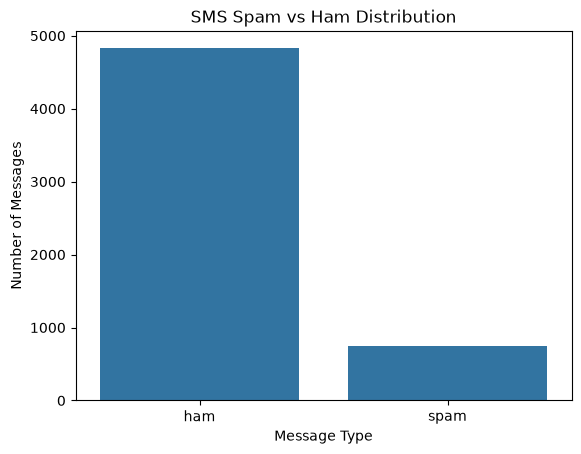

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=df, x="label")

plt.title("SMS Spam vs Ham Distribution")
plt.xlabel("Message Type")
plt.ylabel("Number of Messages")
plt.show()

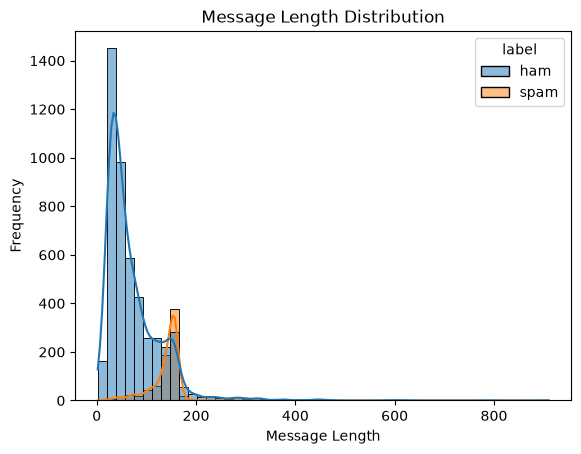

In [12]:
sns.histplot(
    data=df,
    x="message_length",
    hue="label",
    bins=50,
    kde=True
)

plt.title("Message Length Distribution")
plt.xlabel("Message Length")
plt.ylabel("Frequency")
plt.show()

In [13]:
print(df.isnull().sum())
print("Duplicates:", df.duplicated().sum())

df["message_length"] = df["message"].apply(len)

print(df.groupby("label")["message_length"].describe())

label             0
message           0
message_length    0
dtype: int64
Duplicates: 403
        count        mean        std   min    25%    50%    75%    max
label                                                                 
ham    4825.0   71.482487  58.440652   2.0   33.0   52.0   93.0  910.0
spam    747.0  138.670683  28.873603  13.0  133.0  149.0  157.0  223.0


In [14]:
# remove the Duplicates
print("Before removing duplicates:", df.shape)

df = df.drop_duplicates().reset_index(drop=True)

print("After removing duplicates:", df.shape)

Before removing duplicates: (5572, 3)
After removing duplicates: (5169, 3)


In [15]:
# new class distribution
print(df["label"].value_counts())

print("\nPercentage:")
print(df["label"].value_counts(normalize=True) * 100)

label
ham     4516
spam     653
Name: count, dtype: int64

Percentage:
label
ham     87.366996
spam    12.633004
Name: proportion, dtype: float64


In [16]:
spam_messages = df[df["label"] == "spam"]

spam_messages[["message", "message_length"]].head(10)

,message,message_length
2,Free entry in 2 a wkly comp to win FA Cup fina...,155
5,FreeMsg Hey there darling it's been 3 week's n...,147
8,WINNER!! As a valued network customer you have...,157
9,Had your mobile 11 months or more? U R entitle...,154
11,"SIX chances to win CASH! From 100 to 20,000 po...",136
12,URGENT! You have won a 1 week FREE membership ...,155
15,"XXXMobileMovieClub: To use your credit, click ...",149
19,England v Macedonia - dont miss the goals/team...,155
34,Thanks for your subscription to Ringtone UK yo...,158
42,07732584351 - Rodger Burns - MSG = We tried to...,172


In [17]:
ham_messages = df[df["label"] == "ham"]

ham_messages[["message", "message_length"]].head(10)

,message,message_length
0,"Go until jurong point, crazy.. Available only ...",111
1,Ok lar... Joking wif u oni...,29
3,U dun say so early hor... U c already then say...,49
4,"Nah I don't think he goes to usf, he lives aro...",61
6,Even my brother is not like to speak with me. ...,77
7,As per your request 'Melle Melle (Oru Minnamin...,160
10,I'm gonna be home soon and i don't want to tal...,109
13,I've been searching for the right words to tha...,196
14,I HAVE A DATE ON SUNDAY WITH WILL!!,35
16,Oh k...i'm watching here:),26


In [19]:
# create ML dataset
X = df["message"]
y = df["label"]

y = y.map({
    "ham": 0,
    "spam": 1
})

y.value_counts()

label
0    4516
1     653
Name: count, dtype: int64

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4135
Testing samples: 1034


In [21]:
print(df["label"].value_counts())

print(y.value_counts())

print(
    "Train:",
    X_train.shape,
    "Test:",
    X_test.shape
)

label
ham     4516
spam     653
Name: count, dtype: int64
label
0    4516
1     653
Name: count, dtype: int64
Train: (4135,) Test: (1034,)


In [22]:
# tfidfvectorization
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

In [23]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [24]:
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (4135, 5713)
Testing TF-IDF shape: (1034, 5713)


In [27]:
#logistic regression
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

In [28]:
#model evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

print(classification_report(
    y_test,
    y_pred,
    target_names=["ham", "spam"]
))

Accuracy : 0.9738878143133463
Precision: 0.90625
Recall   : 0.8854961832061069
F1 Score : 0.8957528957528957
              precision    recall  f1-score   support

         ham       0.98      0.99      0.99       903
        spam       0.91      0.89      0.90       131

    accuracy                           0.97      1034
   macro avg       0.94      0.94      0.94      1034
weighted avg       0.97      0.97      0.97      1034



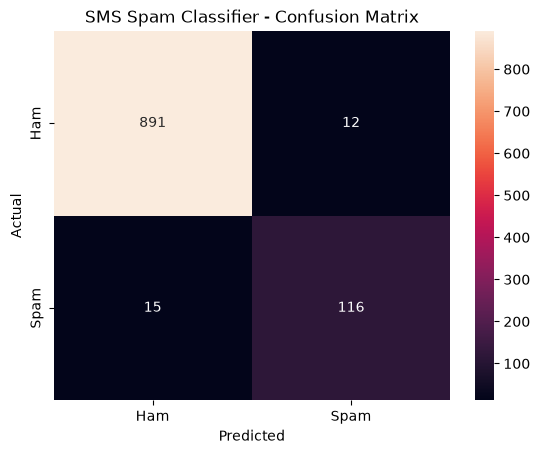

In [29]:
#confusion matrix
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SMS Spam Classifier - Confusion Matrix")
plt.show()

In [30]:
#Error anlysis
results = pd.DataFrame({
    "message": X_test,
    "actual": y_test,
    "predicted": y_pred
})

errors = results[results["actual"] != results["predicted"]]

print("Number of incorrect predictions:", len(errors))

errors

Number of incorrect predictions: 27


,message,actual,predicted
1262,Your daily text from me – a favour this time,0,1
5137,Want explicit SEX in 30 secs? Ring 02073162414...,1,0
521,You will recieve your tone within the next 24h...,1,0
5139,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...,1,0
75,I am waiting machan. Call me once you free.,0,1
487,Are you free now?can i call now?,0,1
1423,Hi its LUCY Hubby at meetins all day Fri & I w...,1,0
3949,Missed call alert. These numbers called but le...,1,0
4806,K k:) sms chat with me.,0,1
2303,Babe: U want me dont u baby! Im nasty and have...,1,0


In [31]:
false_negatives = results[
    (results["actual"] == 1) &
    (results["predicted"] == 0)
]

print("False Negatives:", len(false_negatives))

false_negatives

False Negatives: 15


,message,actual,predicted
5137,Want explicit SEX in 30 secs? Ring 02073162414...,1,0
521,You will recieve your tone within the next 24h...,1,0
5139,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...,1,0
1423,Hi its LUCY Hubby at meetins all day Fri & I w...,1,0
3949,Missed call alert. These numbers called but le...,1,0
2303,Babe: U want me dont u baby! Im nasty and have...,1,0
4499,Check Out Choose Your Babe Videos @ sms.shsex....,1,0
2180,88066 FROM 88066 LOST 3POUND HELP,1,0
3890,In The Simpsons Movie released in July 2007 na...,1,0
3332,Xmas & New Years Eve tickets are now on sale f...,1,0


In [32]:
false_positives = results[
    (results["actual"] == 0) &
    (results["predicted"] == 1)
]

print("False Positives:", len(false_positives))

false_positives

False Positives: 12


,message,actual,predicted
1262,Your daily text from me – a favour this time,0,1
75,I am waiting machan. Call me once you free.,0,1
487,Are you free now?can i call now?,0,1
4806,K k:) sms chat with me.,0,1
1934,See the forwarding message for proof,0,1
805,On the road so cant txt,0,1
3586,"Aight, can you text me the address?",0,1
1620,Glad to see your reply.,0,1
2199,Dont you have message offer,0,1
1981,.Please charge my mobile when you get up in mo...,0,1


In [33]:
#Multinomial Naive Bayes
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

nb_pred = nb_model.predict(X_test_tfidf)

print(classification_report(
    y_test,
    nb_pred,
    target_names=["ham", "spam"]
))

nb_accuracy = accuracy_score(y_test, nb_pred)
nb_precision = precision_score(y_test, nb_pred)
nb_recall = recall_score(y_test, nb_pred)
nb_f1 = f1_score(y_test, nb_pred)

print("Naive Bayes")
print("Accuracy :", nb_accuracy)
print("Precision:", nb_precision)
print("Recall   :", nb_recall)
print("F1 Score :", nb_f1)


              precision    recall  f1-score   support

         ham       0.97      1.00      0.98       903
        spam       1.00      0.76      0.86       131

    accuracy                           0.97      1034
   macro avg       0.98      0.88      0.92      1034
weighted avg       0.97      0.97      0.97      1034

Naive Bayes
Accuracy : 0.9690522243713733
Precision: 1.0
Recall   : 0.7557251908396947
F1 Score : 0.8608695652173913


In [34]:
#SVM
from sklearn.svm import LinearSVC

svm_model = LinearSVC(
    class_weight="balanced",
    random_state=42
)

svm_model.fit(X_train_tfidf, y_train)

svm_pred = svm_model.predict(X_test_tfidf)

svm_accuracy = accuracy_score(y_test, svm_pred)
svm_precision = precision_score(y_test, svm_pred)
svm_recall = recall_score(y_test, svm_pred)
svm_f1 = f1_score(y_test, svm_pred)

print("Linear SVM")
print("Accuracy :", svm_accuracy)
print("Precision:", svm_precision)
print("Recall   :", svm_recall)
print("F1 Score :", svm_f1)

print(classification_report(
    y_test,
    svm_pred,
    target_names=["ham", "spam"]
))

Linear SVM
Accuracy : 0.9787234042553191
Precision: 0.936
Recall   : 0.8931297709923665
F1 Score : 0.9140625
              precision    recall  f1-score   support

         ham       0.98      0.99      0.99       903
        spam       0.94      0.89      0.91       131

    accuracy                           0.98      1034
   macro avg       0.96      0.94      0.95      1034
weighted avg       0.98      0.98      0.98      1034



In [35]:
final_results = pd.DataFrame({
    "message": X_test,
    "actual": y_test,
    "predicted": svm_pred
})

errors = final_results[
    final_results["actual"] != final_results["predicted"]
]

print("Total errors:", len(errors))
errors

Total errors: 22


,message,actual,predicted
1262,Your daily text from me – a favour this time,0,1
5137,Want explicit SEX in 30 secs? Ring 02073162414...,1,0
521,You will recieve your tone within the next 24h...,1,0
1611,Hi if ur lookin 4 saucy daytime fun wiv busty ...,1,0
5139,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...,1,0
487,Are you free now?can i call now?,0,1
3599,Please protect yourself from e-threats. SIB ne...,0,1
1423,Hi its LUCY Hubby at meetins all day Fri & I w...,1,0
3949,Missed call alert. These numbers called but le...,1,0
4806,K k:) sms chat with me.,0,1


In [36]:
false_negatives = final_results[
    (final_results["actual"] == 1) &
    (final_results["predicted"] == 0)
]

print("False negatives:", len(false_negatives))
false_negatives

False negatives: 14


,message,actual,predicted
5137,Want explicit SEX in 30 secs? Ring 02073162414...,1,0
521,You will recieve your tone within the next 24h...,1,0
1611,Hi if ur lookin 4 saucy daytime fun wiv busty ...,1,0
5139,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...,1,0
1423,Hi its LUCY Hubby at meetins all day Fri & I w...,1,0
3949,Missed call alert. These numbers called but le...,1,0
2303,Babe: U want me dont u baby! Im nasty and have...,1,0
4499,Check Out Choose Your Babe Videos @ sms.shsex....,1,0
3890,In The Simpsons Movie released in July 2007 na...,1,0
5062,"Latest News! Police station toilet stolen, cop...",1,0


In [37]:
false_positives = final_results[
    (final_results["actual"] == 0) &
    (final_results["predicted"] == 1)
]

print("False positives:", len(false_positives))
false_positives

False positives: 8


,message,actual,predicted
1262,Your daily text from me – a favour this time,0,1
487,Are you free now?can i call now?,0,1
3599,Please protect yourself from e-threats. SIB ne...,0,1
4806,K k:) sms chat with me.,0,1
805,On the road so cant txt,0,1
1620,Glad to see your reply.,0,1
1981,.Please charge my mobile when you get up in mo...,0,1
4416,I (Career Tel) have added u as a contact on IN...,0,1


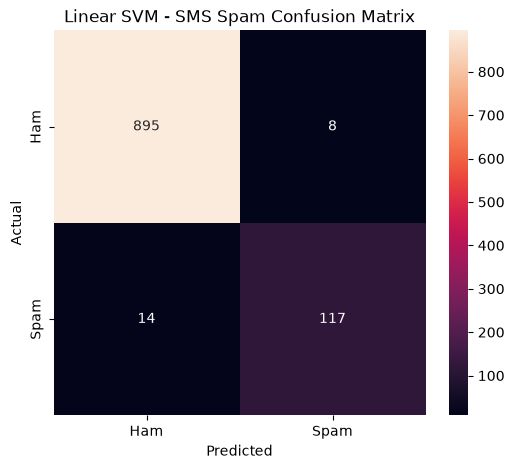

In [38]:
cm = confusion_matrix(y_test, svm_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Linear SVM - SMS Spam Confusion Matrix")
plt.show()

In [39]:
print("FALSE NEGATIVES")
print("=" * 80)

for message in false_negatives["message"]:
    print(message)
    print("-" * 80)

print("FALSE POSITIVES")
print("=" * 80)

for message in false_positives["message"]:
    print(message)
    print("-" * 80)

FALSE NEGATIVES
Want explicit SEX in 30 secs? Ring 02073162414 now! Costs 20p/min Gsex POBOX 2667 WC1N 3XX
--------------------------------------------------------------------------------
You will recieve your tone within the next 24hrs. For Terms and conditions please see Channel U Teletext Pg 750
--------------------------------------------------------------------------------
Hi if ur lookin 4 saucy daytime fun wiv busty married woman Am free all next week Chat now 2 sort time 09099726429 JANINExx Calls£1/minMobsmoreLKPOBOX177HP51FL
--------------------------------------------------------------------------------
ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE MINS. INDIA CUST SERVs SED YES. L8ER GOT MEGA BILL. 3 DONT GIV A SHIT. BAILIFF DUE IN DAYS. I O £250 3 WANT £800
--------------------------------------------------------------------------------
Hi its LUCY Hubby at meetins all day Fri & I will B alone at hotel U fancy cumin over? Pls leave msg 2day 09099726395 Lucy x Calls£1/minMo

In [40]:
#character level tfidf svm
from sklearn.feature_extraction.text import TfidfVectorizer

char_tfidf = TfidfVectorizer(
    analyzer="char",
    ngram_range=(3, 5),
    min_df=2,
    max_features=30000
)

X_train_char = char_tfidf.fit_transform(X_train)
X_test_char = char_tfidf.transform(X_test)

print("Training shape:", X_train_char.shape)
print("Testing shape:", X_test_char.shape)

char_svm = LinearSVC(
    class_weight="balanced",
    random_state=42
)

char_svm.fit(X_train_char, y_train)

char_pred = char_svm.predict(X_test_char)

char_accuracy = accuracy_score(y_test, char_pred)
char_precision = precision_score(y_test, char_pred)
char_recall = recall_score(y_test, char_pred)
char_f1 = f1_score(y_test, char_pred)

print("Character TF-IDF + Linear SVM")
print("Accuracy :", char_accuracy)
print("Precision:", char_precision)
print("Recall   :", char_recall)
print("F1 Score :", char_f1)


Training shape: (4135, 30000)
Testing shape: (1034, 30000)
Character TF-IDF + Linear SVM
Accuracy : 0.9874274661508704
Precision: 0.9916666666666667
Recall   : 0.9083969465648855
F1 Score : 0.9482071713147411


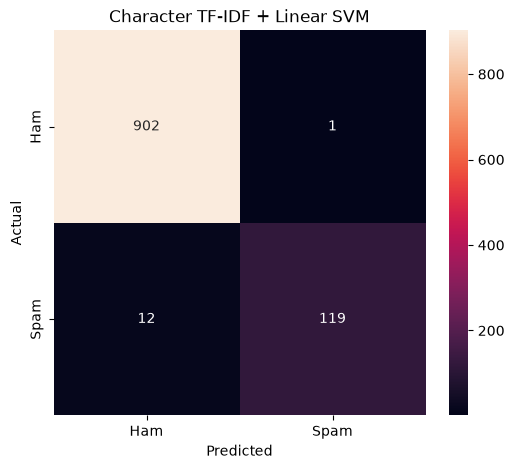

In [41]:
char_cm = confusion_matrix(y_test, char_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    char_cm,
    annot=True,
    fmt="d",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Character TF-IDF + Linear SVM")
plt.show()

In [42]:
char_results = pd.DataFrame({
    "message": X_test,
    "actual": y_test,
    "predicted": char_pred
})

char_errors = char_results[
    char_results["actual"] != char_results["predicted"]
]

print("Total errors:", len(char_errors))

char_false_negatives = char_results[
    (char_results["actual"] == 1) &
    (char_results["predicted"] == 0)
]

char_false_positives = char_results[
    (char_results["actual"] == 0) &
    (char_results["predicted"] == 1)
]

print("False negatives:", len(char_false_negatives))
print("False positives:", len(char_false_positives))

Total errors: 13
False negatives: 12
False positives: 1


In [43]:
import joblib

joblib.dump(
    char_tfidf,
    "../models/tfidf_char_vectorizer.joblib"
)

joblib.dump(
    char_svm,
    "../models/spam_classifier.joblib"
)

['../models/spam_classifier.joblib']

In [44]:
import os

print(os.listdir("../models"))

['spam_classifier.joblib', 'tfidf_char_vectorizer.joblib']


In [45]:
loaded_vectorizer = joblib.load(
    "../models/tfidf_char_vectorizer.joblib"
)

loaded_model = joblib.load(
    "../models/spam_classifier.joblib"
)

In [46]:
test_message = [
    "Congratulations! You have won a free prize. Call now to claim."
]

test_features = loaded_vectorizer.transform(test_message)

prediction = loaded_model.predict(test_features)[0]

if prediction == 1:
    print("SPAM")
else:
    print("HAM")

SPAM


In [47]:
test_message = [
    "Hey, are you coming home for dinner?"
]

test_features = loaded_vectorizer.transform(test_message)

prediction = loaded_model.predict(test_features)[0]

if prediction == 1:
    print("SPAM")
else:
    print("HAM")

HAM
